In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("Social_Network_Ads.csv")
x = dataset.iloc[:, [1,2]].values
y = dataset.iloc[:, 3].values

In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 0)


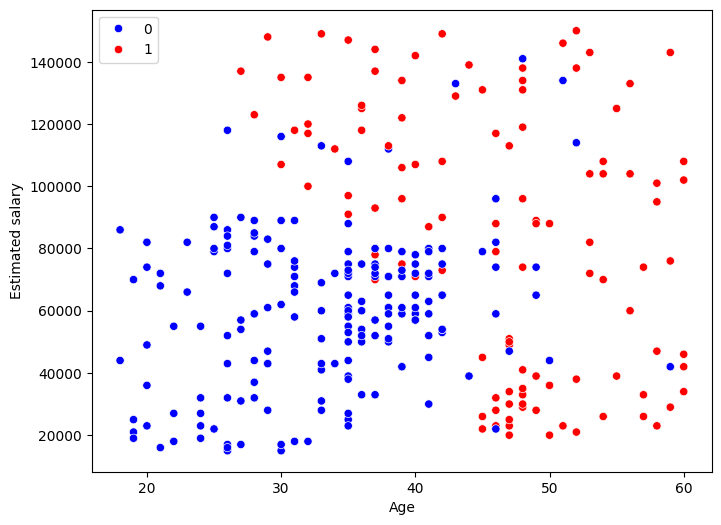

In [4]:
import seaborn as sns
plt.figure(figsize= (8,6))
sns.scatterplot(x=x_train[:,0], y=x_train[:,1], hue = y_train, palette={
0: 'blue', 1:'red'}, marker = 'o')
plt.xlabel("Age")
plt.ylabel("Estimated salary")
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

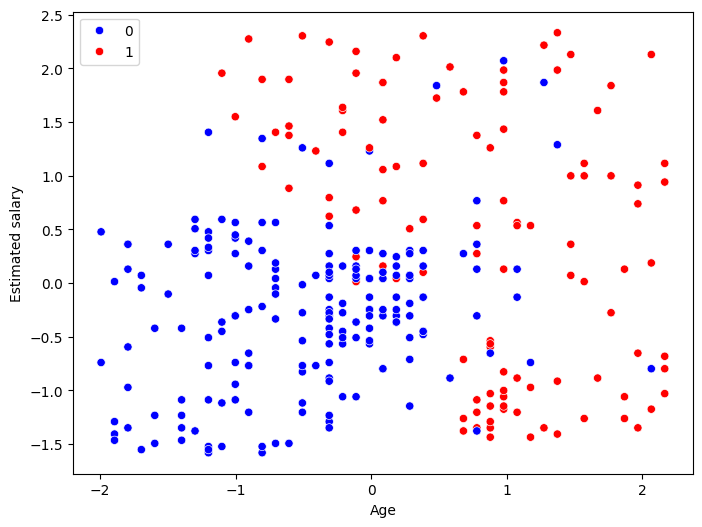

In [6]:
import seaborn as sns
plt.figure(figsize= (8,6))
sns.scatterplot(x=x_train[:,0], y=x_train[:,1], hue = y_train, palette={
0: 'blue', 1:'red'}, marker = 'o')
plt.xlabel("Age")
plt.ylabel("Estimated salary")
plt.show()

In [7]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(x_train, y_train)

LogisticRegression()

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, confusion_matrix

y_pred = classifier.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))


Accuracy: 89.00%


In [9]:
print("Coefficients:", classifier.coef_)
print("Intercept:", classifier.intercept_)

Coefficients: [[2.07665837 1.11008221]]
Intercept: [-0.95217247]


y = mx + c

y = [2.07665837* age + 1.11008221* salary] + [-0.95217247] = 0

1.11008221* y = -2.07665837* x + 0.95217247


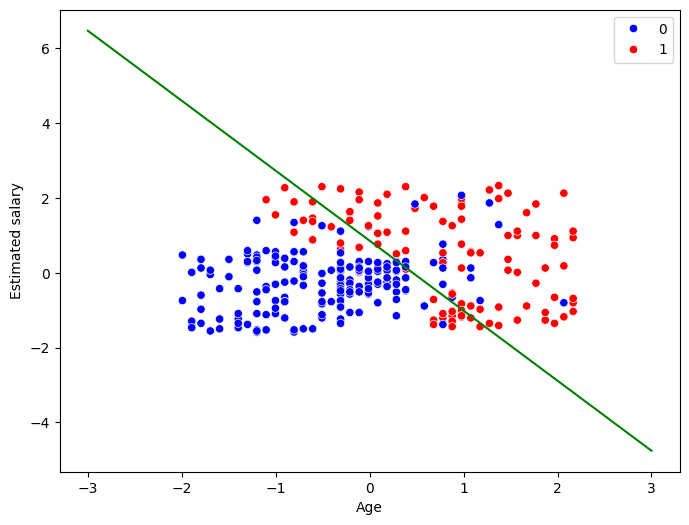

In [10]:
import seaborn as sns
x1 = np.linspace(-3,3, 100)
x2 = (-2.07665837*x1 + 0.95217247) / 1.11008221
plt.figure(figsize= (8,6))
plt.plot(x1, x2, color="green")

sns.scatterplot(x=x_train[:,0], y=x_train[:,1], hue = y_train, palette={
0: 'blue', 1:'red'}, marker = 'o')
plt.xlabel("Age")
plt.ylabel("Estimated salary")
plt.show()

In [11]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [12]:
y_pred = knn.predict(x_test)
print(f"Test Accuracy (k=5): {accuracy_score(y_test, y_pred):.2f}")


Test Accuracy (k=5): 0.93


In [13]:
x1_vals = np.linspace(-3, 3, 100)
x2_vals = np.linspace(-3,3,400)
x1, x2 = np.meshgrid(x1_vals, x2_vals)

In [14]:
z = knn.predict(np.c_[x1.ravel(), x2.ravel()])
z = z.reshape(x1.shape)

In [15]:
print(z)

[[0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


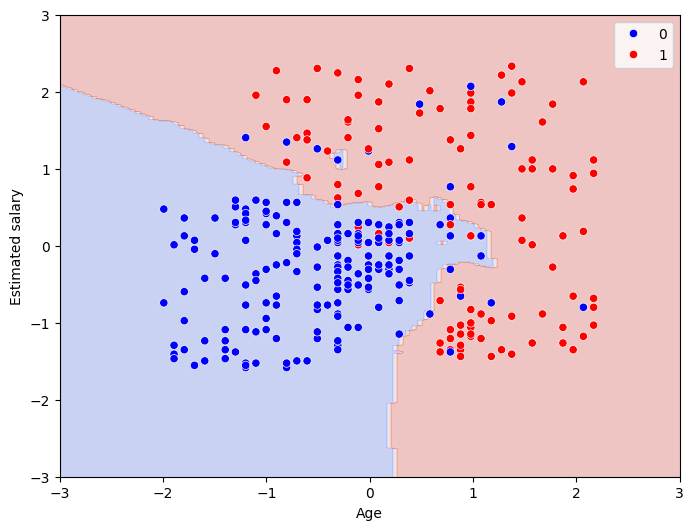

In [16]:
import seaborn as sns
plt.figure(figsize= (8,6))
plt.contourf(x1, x2, z, cmap = plt.cm.coolwarm, alpha = 0.3)

sns.scatterplot(x=x_train[:,0], y=x_train[:,1], hue = y_train, palette={
0: 'blue', 1:'red'}, marker = 'o')
plt.xlabel("Age")
plt.ylabel("Estimated salary")
plt.show()

In [17]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(x_train, y_train)

SVC(kernel='linear', random_state=0)

In [18]:
y_pred = classifier.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 90.00%


/tmp/ipykernel_3569/3534901794.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


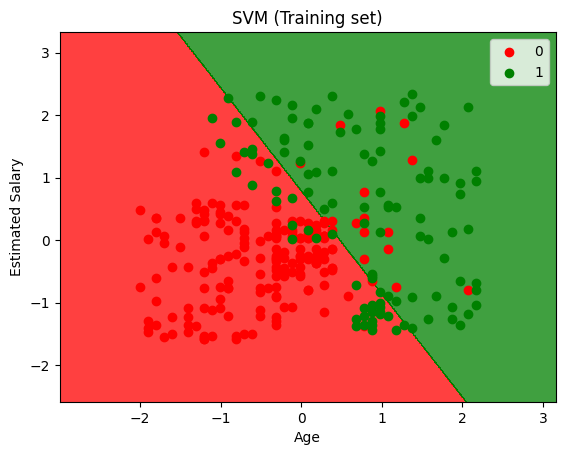

In [19]:
from matplotlib.colors import ListedColormap
x_set, y_set = x_train, y_train
x1, x2 = np.meshgrid(np.arange(start = x_set[:, 0].min() - 1, stop = x_set[:,0].max() + 1, step = 0.01),
                     np.arange(start = x_set[:, 1].min() - 1, stop = x_set[:,1].max() + 1, step = 0.01))
plt.contourf(x1, x2, classifier.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))

plt.xlim(x1.min(), x1.max())
plt.ylim(x2.min(), x2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)

plt.title('SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()


In [20]:
print(classifier.coef_)
print(classifier.intercept_)

[[1.60291291 0.97138722]]
[-0.76862169]


In [21]:
weights = classifier.coef_
bias = classifier.intercept_

In [22]:
with open("svm_model.h", "w") as f:
  f.write(f"#define NUM_CLASSES {weights.shape[0]}\n")
  f.write(f"#define NUM_FEATURES {weights.shape[1]}\n\n")

  f.write("double weights[NUM_CLASSES][NUM_FEATURES] = {\n")
  for row in weights:
    f.write("   {" + ", ".join(f"{v:.10f}" for v in row) + "}, \n")
  f.write("};\n\n")

  f.write("double bias[NUM_CLASSES] = {" + ", ".join(f"{b:.10f}" for b in bias) + "};\n")

  print("Exported SVM model to svm_model.h")

Exported SVM model to svm_model.h


In [23]:
mean = sc.mean_
scale = sc.scale_

with open("scaler.h", "w") as f:
  f.write(f"#define NUM_FEATURES {len(mean)}\n\n")

  f.write("double mean[NUM_FEATURES] = {\n")
  f.write("    " + ", ".join(f"{m:.10f}" for m in mean) + "\n};\n\n")

  f.write("double scale[NUM_FEATURES] = {\n")
  f.write("    " + ", ".join(f"{s:.10f}" for s in scale) + "\n};\n")

  print("Exported scaler parameters to scaler.h")

Exported scaler parameters to scaler.h
